# Pracovní notebook pro EDA, KPI a následnou SDA

In [1]:
import sys
import pandas as pd
import pyodbc
import matplotlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr, spearmanr

In [2]:
# ============================================================
# 1. SQL PŘIPOJENÍ
#
# Cíl:
# Připojit se k databázi fund_performance_analytics,
# ze které budeme načítat data pro analytickou část projektu.
# ============================================================

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=(localdb)\\DataAnalyticsLocalDB;"
    "DATABASE=fund_performance_analytics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)

connection = pyodbc.connect(
    connection_string
)

print("Připojení k SQL Serveru je OK.")

Připojení k SQL Serveru je OK.


In [3]:
# ============================================================
# 2. SQL DOTAZ PRO ANALYTICKÁ DATA
#
# Cíl:
# Načíst data potřebná pro analýzu:
# - klíč fondu,
# - název fondu,
# - kategorii fondu,
# - datum NAV,
# - hodnotu NAV.
#
# FactFundPrice obsahuje NAV hodnotu.
# DimFund dodává informace o fondu.
# DimDate dodává skutečné kalendářní datum.
# ============================================================

query = """
SELECT
    f.fund_key,
    f.fund_name,
    f.fund_category,
    d.date_key,
    d.calendar_date,
    p.nav_value
FROM analytics.FactFundPrice p
JOIN analytics.DimFund f
    ON p.fund_key = f.fund_key
JOIN analytics.DimDate d
    ON p.date_key = d.date_key
ORDER BY
    f.fund_name,
    d.calendar_date;
"""

In [4]:
# ============================================================
# 3. NAČTENÍ DAT Z SQL DO PANDAS
#
# Cíl:
# Načíst výsledek SQL dotazu přímo do DataFrame.
#
# pd.read_sql():
# SQL dotaz + databázové spojení
# → pandas DataFrame
# ============================================================

df = pd.read_sql(
    query,
    connection
)

C:\Users\frant\AppData\Local\Temp\ipykernel_45356\3862757984.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [5]:
# ============================================================
# 4. ZÁKLADNÍ KONTROLA NAČTENÝCH DAT
#
# Cíl:
# Ověřit, že:
# - DataFrame není prázdný,
# - datum má správný datový typ,
# - NAV je číselná hodnota.
# ============================================================

if df.empty:
    print("CHYBA: ze SQL nebyla načtena žádná data.")
    connection.close()

    sys.exit(1)

df["calendar_date"] = pd.to_datetime(
    df["calendar_date"]
)

df["nav_value"] = pd.to_numeric(
    df["nav_value"]
)

In [6]:
# ============================================================
# 5. ZÁKLADNÍ KONTROLA DATASETU
#
# Cíl:
# Získat základní přehled o analytickém datasetu.
# ============================================================

print()
print("=" * 60)
print("ZÁKLADNÍ KONTROLA DAT")
print("=" * 60)
print(
    "Počet načtených řádků: "
    + str(len(df))
)
print(
    "Počet fondů: "
    + str(df["fund_key"].nunique())
)
print(
    "První datum v datech: "
    + str(df["calendar_date"].min().date())
)
print(
    "Poslední datum v datech: "
    + str(df["calendar_date"].max().date())
)


ZÁKLADNÍ KONTROLA DAT
Počet načtených řádků: 19601
Počet fondů: 6
První datum v datech: 2005-01-03
Poslední datum v datech: 2026-09-29


In [7]:
# ============================================================
# 6. UKONČENÍ SQL SPOJENÍ
#
# Cíl:
# Po načtení dat korektně uzavřít databázové spojení.
#
# Další analytická práce bude probíhat nad DataFrame v paměti.
# ============================================================

connection.close()

print()
print("Připojení k SQL Serveru bylo ukončeno.")


Připojení k SQL Serveru bylo ukončeno.


In [8]:
# ============================================================
# PLÁN ANALÝZY
# 1. Určit společné analytické období.
# 2. Vytvořit pracovní dataset pro společné období.
# 3. Připravit základní analytické proměnné:
#    - denní výnos;
#    - normalizované NAV;
#    - kumulativní výnos;
#    - průběžné maximum NAV;
#    - drawdown;
#    - rolling 12M return.
# 4. Provést EDA:
#    - vývoj hodnoty a výnosu;
#    - riziko a propady;
#    - stabilita výkonnosti;
#    - nejlepší a nejslabší období;
#    - rozdíly mezi kategoriemi;
#    - korelace a společné poklesy.
# 5. Spočítat a dokončit hlavní KPI:
#    - cumulative return;
#    - CAGR;
#    - annualized volatility;
#    - maximum drawdown;
#    - recovery time.
# 6. Formulovat hypotézy na základě EDA.
# 7. Provést vybrané SDA testy.
# 8. Připravit analytické výstupy pro SQL a Power BI.
# 9. Shrnutí a interpretace výsledků podle
#    analytických otázek.
# ============================================================

In [9]:
# ============================================================
# 1. SPOLEČNÉ ANALYTICKÉ OBDOBÍ
#
# Cíl:
# Zjistit první a poslední dostupné datum pro každý fond
# a z těchto hodnot určit období, ve kterém mají data
# všechny fondy.
#
# Společný začátek:
# nejpozdější first_date.
#
# Společný konec:
# nejdřívější last_date.
# ============================================================

fund_date_ranges = (
    df.groupby(
        [
            "fund_key",
            "fund_name"
        ],
        as_index=False
    )
    .agg(
        first_date=("calendar_date", "min"),
        last_date=("calendar_date", "max")
    )
)

print()
print("=" * 60)
print("ROZSAH DAT PRO JEDNOTLIVÉ FONDY")
print("=" * 60)
print(
    fund_date_ranges
)

common_start_date = (
    fund_date_ranges["first_date"].max()
)

common_end_date = (
    fund_date_ranges["last_date"].min()
)

print()
print("=" * 60)
print("SPOLEČNÉ ANALYTICKÉ OBDOBÍ")
print("=" * 60)
print(
    "Začátek společného období: "
    + str(common_start_date.date())
)
print(
    "Konec společného období: "
    + str(common_end_date.date())
)


ROZSAH DAT PRO JEDNOTLIVÉ FONDY
   fund_key                                 fund_name first_date  last_date
0         1  ČSOB Akciový pro digitalizaci zodpovědný 2023-04-28 2026-09-29
1         2                 ČSOB Akciový srdce Evropy 2007-05-10 2026-09-29
2         3                ČSOB Premium Velmi odvážný 2016-08-02 2026-09-29
3         4     ČSOB Premium Velmi odvážný zodpovědný 2022-06-01 2026-09-25
4         5                           ČSOB Krátkodobý 2005-01-03 2026-09-29
5         6                          ČSOB Dluhopisový 2005-12-31 2026-09-25

SPOLEČNÉ ANALYTICKÉ OBDOBÍ
Začátek společného období: 2023-04-28
Konec společného období: 2026-09-25


In [10]:
# ============================================================
# 2. PRACOVNÍ DATASET PRO SPOLEČNÉ OBDOBÍ
#
# Cíl:
# Vytvořit pracovní DataFrame pouze pro období,
# ve kterém mají dostupná data všechny fondy.
#
# Tento DataFrame budeme dále používat pro:
# - EDA,
# - SDA,
# - výpočet KPI,
# - vzájemné porovnání fondů.
# ============================================================

analysis_df = df[
    df["calendar_date"].between(
        common_start_date,
        common_end_date
    )
].copy()

print()
print("=" * 60)
print("KONTROLA SPOLEČNÉHO OBDOBÍ")
print("=" * 60)
print(
    "Počet řádků ve společném období: "
    + str(len(analysis_df))
)
print(
    "Počet fondů ve společném období: "
    + str(analysis_df["fund_key"].nunique())
)
print(
    "První datum: "
    + str(analysis_df["calendar_date"].min().date())
)
print(
    "Poslední datum: "
    + str(analysis_df["calendar_date"].max().date())
)


KONTROLA SPOLEČNÉHO OBDOBÍ
Počet řádků ve společném období: 4985
Počet fondů ve společném období: 6
První datum: 2023-04-28
Poslední datum: 2026-09-25


In [11]:
# ============================================================
# 3. PŘÍPRAVA ZÁKLADNÍCH ANALYTICKÝCH PROMĚNNÝCH
# 3.1 DENNÍ VÝNOS
#
# Cíl:
# Spočítat procentní změnu NAV mezi dvěma po sobě
# dostupnými oceněními pro každý fond zvlášť.
#
# Denní výnos:
# (aktuální NAV / předchozí NAV) - 1
# ============================================================

# Seřazení dat podle fondu a data.
analysis_df = (
    analysis_df
    .sort_values(
        by=[
            "fund_key",
            "calendar_date"
        ]
    )
    .reset_index(drop=True)
)

# Rozdělení NAV hodnot podle fondů.

fund_groups = analysis_df.groupby(
    "fund_key"
)

nav_by_fund = fund_groups[
    "nav_value"
]

# Výpočet změny oproti předchozímu dostupnému ocenění.

daily_returns = nav_by_fund.pct_change()

analysis_df["daily_return"] = daily_returns

print()
print("=" * 60)
print("KONTROLA DENNÍCH VÝNOSŮ")
print("=" * 60)
print(
    "Počet chybějících daily_return: "
    + str(analysis_df["daily_return"].isna().sum())
)
print(
    "Minimální denní výnos: "
    + str(analysis_df["daily_return"].min())
)
print(
    "Maximální denní výnos: "
    + str(analysis_df["daily_return"].max())
)


KONTROLA DENNÍCH VÝNOSŮ
Počet chybějících daily_return: 6
Minimální denní výnos: -0.07291542549388741
Maximální denní výnos: 0.076518320855542


In [12]:
# ============================================================
# 3.2 NORMALIZOVANÉ NAV A KUMULATIVNÍ VÝNOS
#
# Cíl:
# Převést fondy na společnou základnu 100
# a spočítat výnos od začátku společného období.
# ============================================================

# Získání počáteční NAV hodnoty pro každý fond.

first_nav = (
    analysis_df.groupby(
        [
            "fund_key",
            "fund_name"
        ],
        as_index=False
    )
    .agg(
        first_nav=("nav_value", "first")
    )
)

print()
print("=" * 60)
print("POČÁTEČNÍ NAV VE SPOLEČNÉM OBDOBÍ")
print("=" * 60)
print(
    first_nav.to_string(
        index=False
    )
)

# Připojení počáteční NAV ke všem řádkům daného fondu.

analysis_df = analysis_df.merge(
    first_nav[
        [
            "fund_key",
            "first_nav"
        ]
    ],
    on="fund_key",
    how="left"
)

# Výpočet normalizovaného NAV a kumulativního výnosu.

analysis_df["normalized_nav"] = (
    analysis_df["nav_value"]
    / analysis_df["first_nav"]
    * 100
)

analysis_df["cumulative_return"] = (
    analysis_df["nav_value"]
    / analysis_df["first_nav"]
    - 1
)


POČÁTEČNÍ NAV VE SPOLEČNÉM OBDOBÍ
 fund_key                                fund_name  first_nav
        1 ČSOB Akciový pro digitalizaci zodpovědný  1000.0000
        2                ČSOB Akciový srdce Evropy     0.4710
        3               ČSOB Premium Velmi odvážný  1358.4100
        4    ČSOB Premium Velmi odvážný zodpovědný     0.9941
        5                          ČSOB Krátkodobý   135.4090
        6                         ČSOB Dluhopisový     1.4561


In [13]:
# ============================================================
# 3.3 PRŮBĚŽNÉ MAXIMUM NAV A DRAWDOWN
#
# Cíl:
# Připravit průběžné maximum NAV a drawdown,
# které použijeme při analýze rizika a propadů.
# ============================================================

# Výpočet průběžného maxima NAV pro každý fond.

analysis_df["running_max_nav"] = (
    analysis_df
    .groupby("fund_key")["nav_value"]
    .cummax()
)

# Výpočet drawdownu vůči dosavadnímu maximu NAV.

analysis_df["drawdown"] = (
    analysis_df["nav_value"]
    / analysis_df["running_max_nav"]
    - 1
)

In [14]:
# ============================================================
# 3.4 ROLLING 12M RETURN
#
# Cíl:
# Připravit rolling 12M return jako změnu NAV vůči hodnotě
# před 252 dostupnými oceněními.
#
# Jde o aproximaci 12 měsíců založenou na počtu
# obchodních / oceněných dnů.
# ============================================================

# Výpočet rolling 12M return pro každý fond.

analysis_df["rolling_12m_return"] = (
    analysis_df
    .groupby("fund_key")["nav_value"]
    .pct_change(
        periods=252
    )
)

print()
print("=" * 60)
print("KONTROLA ROLLING 12M RETURN")
print("=" * 60)
print(
    "Počet chybějících rolling_12m_return: "
    + str(analysis_df["rolling_12m_return"].isna().sum())
)
print(
    "Minimální rolling 12M return: "
    + str(analysis_df["rolling_12m_return"].min())
)
print(
    "Maximální rolling 12M return: "
    + str(analysis_df["rolling_12m_return"].max())
)


KONTROLA ROLLING 12M RETURN
Počet chybějících rolling_12m_return: 1512
Minimální rolling 12M return: -0.11330642477201347
Maximální rolling 12M return: 0.8880068304025577



SOUHRN DENNÍCH VÝNOSŮ PODLE FONDU
 fund_key                                fund_name fund_category  min_daily_return  max_daily_return  mean_daily_return  median_daily_return
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový         -0.072915          0.076518           0.001488             0.002876
        2                ČSOB Akciový srdce Evropy       Akciový         -0.050907          0.034021           0.001035             0.001056
        3               ČSOB Premium Velmi odvážný       Smíšený         -0.035678          0.034126           0.000591             0.000833
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený         -0.031096          0.033103           0.000566             0.000872
        5                          ČSOB Krátkodobý   Dluhopisový         -0.005963          0.002157           0.000153             0.000146
        6                         ČSOB Dluhopisový   Dluhopisový         -0.010132          0.008878           0.000130

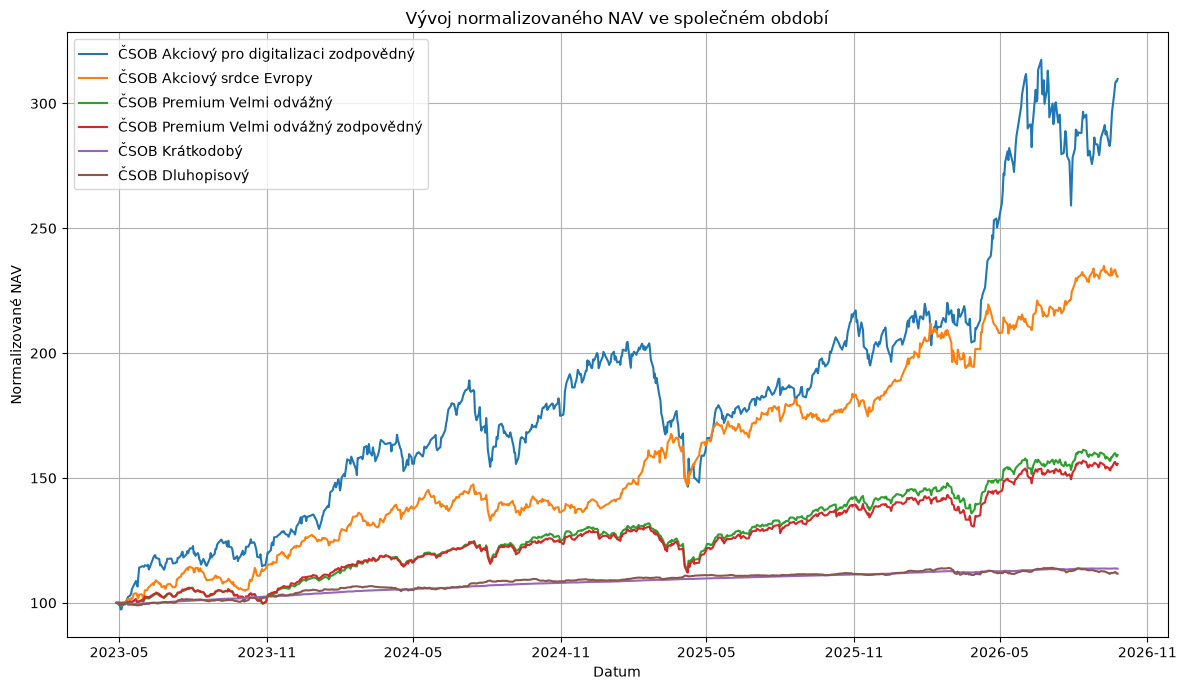

In [15]:
# ============================================================
# 4. EDA
# 4.1 VÝVOJ HODNOTY A VÝNOSU
#
# Analytická otázka:
# Jak se vyvíjela hodnota a výnos jednotlivých fondů
# ve společném období?
#
# Cíl:
# Porovnat:
# - denní výnosy;
# - normalizovaný vývoj NAV;
# - kumulativní výnos.
# ============================================================

# Souhrn denních výnosů podle fondu.

daily_return_summary = (
    analysis_df.groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ],
        as_index=False
    )
    .agg(
        min_daily_return=("daily_return", "min"),
        max_daily_return=("daily_return", "max"),
        mean_daily_return=("daily_return", "mean"),
        median_daily_return=("daily_return", "median")
    )
)

print()
print("=" * 60)
print("SOUHRN DENNÍCH VÝNOSŮ PODLE FONDU")
print("=" * 60)
print(
    daily_return_summary.to_string(
        index=False
    )
)

# Kontrola normalizovaného NAV a kumulativního výnosu.

eda_return_check = (
    analysis_df.groupby(
        [
            "fund_key",
            "fund_name"
        ],
        as_index=False
    )
    .agg(
        first_normalized_nav=("normalized_nav", "first"),
        last_normalized_nav=("normalized_nav", "last"),
        first_cumulative_return=("cumulative_return", "first"),
        last_cumulative_return=("cumulative_return", "last")
    )
)

print()
print("=" * 60)
print("KONTROLA VÝVOJE HODNOTY A VÝNOSU")
print("=" * 60)
print(
    eda_return_check.to_string(
        index=False
    )
)

# Graf vývoje normalizovaného NAV.

plt.figure(
    figsize=(12, 7)
)

for fund_name in analysis_df["fund_name"].unique():
    fund_data = analysis_df[
        analysis_df["fund_name"] == fund_name
    ]

    plt.plot(
        fund_data["calendar_date"],
        fund_data["normalized_nav"],
        label=fund_name
    )

plt.title(
    "Vývoj normalizovaného NAV ve společném období"
)

plt.xlabel(
    "Datum"
)

plt.ylabel(
    "Normalizované NAV"
)

plt.legend()

plt.grid()

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.tight_layout()

plt.show()


MAXIMUM DRAWDOWN PODLE FONDU
 fund_key                                fund_name fund_category  max_drawdown
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový     -0.283459
        2                ČSOB Akciový srdce Evropy       Akciový     -0.123338
        3               ČSOB Premium Velmi odvážný       Smíšený     -0.142418
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený     -0.141350
        5                          ČSOB Krátkodobý   Dluhopisový     -0.005963
        6                         ČSOB Dluhopisový   Dluhopisový     -0.024583

DNA MAXIMUM DRAWDOWNU
 fund_key                                fund_name fund_category calendar_date  nav_value  running_max_nav  drawdown
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový    2025-04-08  1465.2700        2044.9200 -0.283459
        2                ČSOB Akciový srdce Evropy       Akciový    2025-04-07     0.6923           0.7897 -0.123338
        3               ČSOB Premium Velmi 

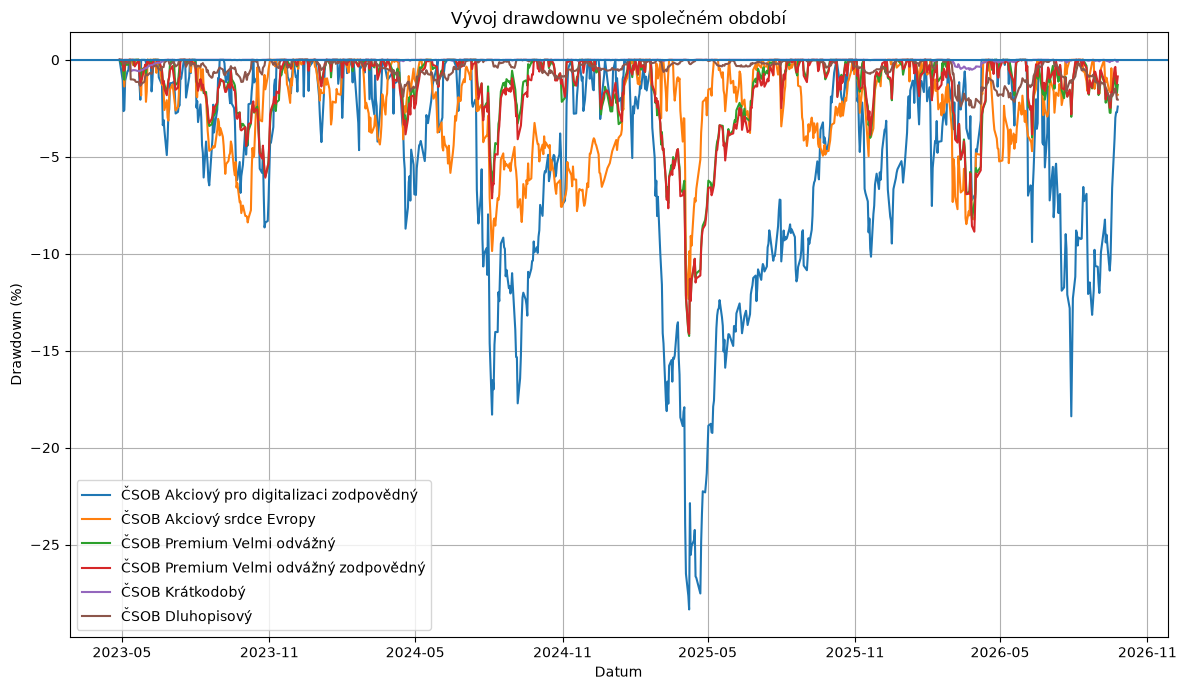

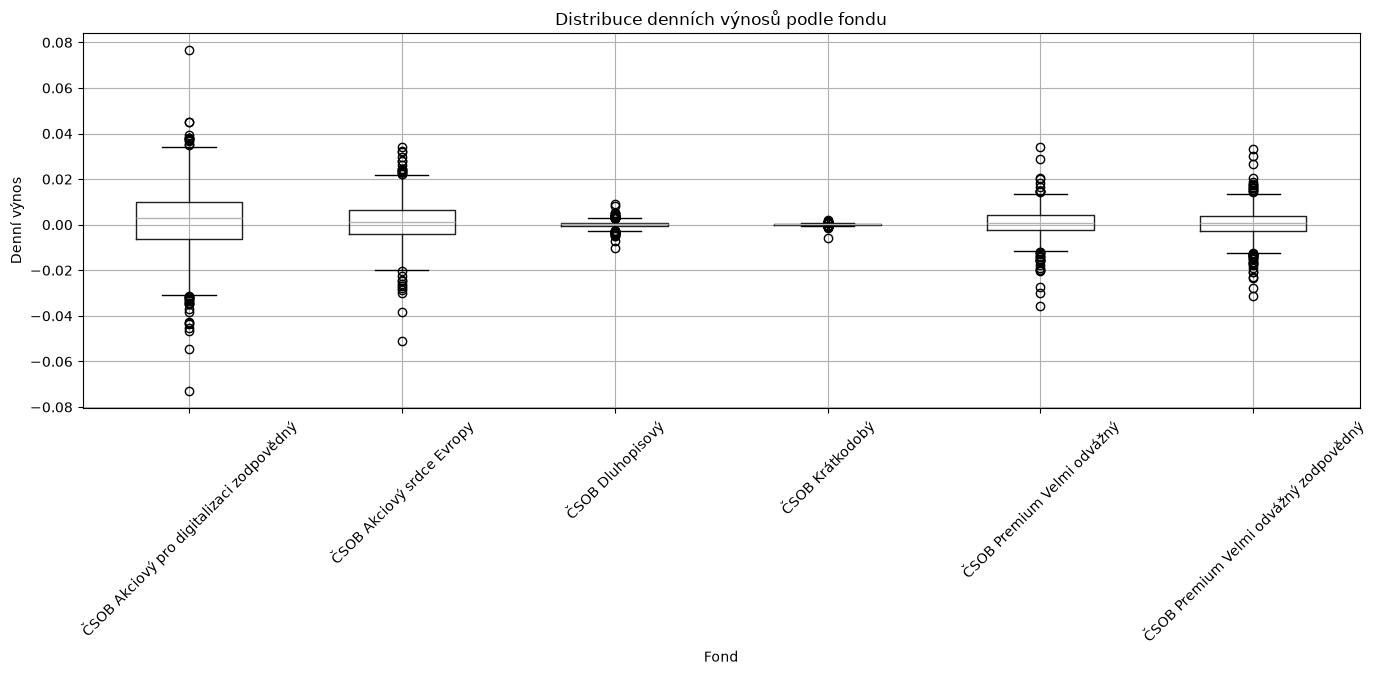

In [16]:
# ============================================================
# 4.2 RIZIKO A PROPADY
#
# Analytická otázka:
# Jak se fondy liší z hlediska rizika a velikosti propadů?
#
# Cíl:
# Porovnat:
# - maximum drawdown;
# - datum dna největšího propadu;
# - dobu zotavení;
# - průběh drawdownů v čase.
# ============================================================

# Výpočet maximum drawdown pro každý fond.

max_drawdown_summary = (
    analysis_df.groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ],
        as_index=False
    )
    .agg(
        max_drawdown=("drawdown", "min")
    )
)

print()
print("=" * 60)
print("MAXIMUM DRAWDOWN PODLE FONDU")
print("=" * 60)
print(
    max_drawdown_summary.to_string(
        index=False
    )
)

# Získání indexu řádku s největším propadem pro každý fond.

max_drawdown_index = (
    analysis_df
    .groupby("fund_key")["drawdown"]
    .idxmin()
)

# Získání řádků s největším propadem pro každý fond.

max_drawdown_rows = analysis_df.loc[
    max_drawdown_index,
    [
        "fund_key",
        "fund_name",
        "fund_category",
        "calendar_date",
        "nav_value",
        "running_max_nav",
        "drawdown"
    ]
]

print()
print("=" * 60)
print("DNA MAXIMUM DRAWDOWNU")
print("=" * 60)
print(
    max_drawdown_rows.to_string(
        index=False
    )
)

# Hledání zotavení z největšího propadu pro každý fond.

recovery_results = []

for _, row in max_drawdown_rows.iterrows():
    fund_key = row["fund_key"]
    fund_name = row["fund_name"]
    fund_category = row["fund_category"]
    drawdown_date = row["calendar_date"]
    previous_max_nav = row["running_max_nav"]

    recovery_data = analysis_df[
        (analysis_df["fund_key"] == fund_key)
        &
        (analysis_df["calendar_date"] > drawdown_date)
    ]

    recovery_data = recovery_data[
        recovery_data["nav_value"] >= previous_max_nav
    ]

    # Fond se během společného období zotavil.

    if not recovery_data.empty:
        recovery_date = (
            recovery_data.iloc[0]["calendar_date"]
        )

        recovery_days = (
            recovery_date - drawdown_date
        ).days

        recovered = True

    # Fond se do konce společného období nezotavil.

    else:
        recovery_date = pd.NaT
        recovery_days = None
        recovered = False

    recovery_results.append(
        {
            "fund_key": fund_key,
            "fund_name": fund_name,
            "fund_category": fund_category,
            "drawdown_date": drawdown_date,
            "previous_max_nav": previous_max_nav,
            "recovery_date": recovery_date,
            "recovery_days": recovery_days,
            "recovered": recovered
        }
    )

# Převod výsledků recovery time do DataFrame.

recovery_summary = pd.DataFrame(
    recovery_results
)

print()
print("=" * 60)
print("DOBA ZOTAVENÍ PO MAXIMUM DRAWDOWNU")
print("=" * 60)
print(
    recovery_summary.to_string(
        index=False
    )
)

# Graf průběhu drawdownu všech fondů.

plt.figure(
    figsize=(12, 7)
)

for fund_name in analysis_df["fund_name"].unique():
    fund_data = analysis_df[
        analysis_df["fund_name"] == fund_name
    ]

    plt.plot(
        fund_data["calendar_date"],
        fund_data["drawdown"] * 100,
        label=fund_name
    )

plt.title(
    "Vývoj drawdownu ve společném období"
)

plt.xlabel(
    "Datum"
)

plt.ylabel(
    "Drawdown (%)"
)

plt.axhline(
    y=0
)

plt.legend()

plt.grid()

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.tight_layout()

plt.show()

# ============================================================
# DISTRIBUCE DENNÍCH VÝNOSŮ
#
# Cíl:
# Doplňkově porovnat:
# - rozptyl denních výnosů,
# - medián,
# - výskyt extrémních hodnot.
# ============================================================

analysis_df.boxplot(
    column="daily_return",
    by="fund_name",
    figsize=(14, 7),
    rot=45
)

plt.title(
    "Distribuce denních výnosů podle fondu"
)

plt.suptitle("")

plt.xlabel(
    "Fond"
)

plt.ylabel(
    "Denní výnos"
)

plt.tight_layout()

plt.show()


ROLLING 12M RETURN PODLE FONDU
 fund_key                                fund_name fund_category  min_rolling_12m_return  max_rolling_12m_return  mean_rolling_12m_return  median_rolling_12m_return
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový               -0.113306                0.888007                 0.328120                   0.339034
        2                ČSOB Akciový srdce Evropy       Akciový                0.092680                0.493572                 0.266919                   0.261658
        3               ČSOB Premium Velmi odvážný       Smíšený               -0.041718                0.354455                 0.153908                   0.165006
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený               -0.044406                0.289183                 0.138895                   0.137576
        5                          ČSOB Krátkodobý   Dluhopisový                0.024270                0.062340                 0.040403      

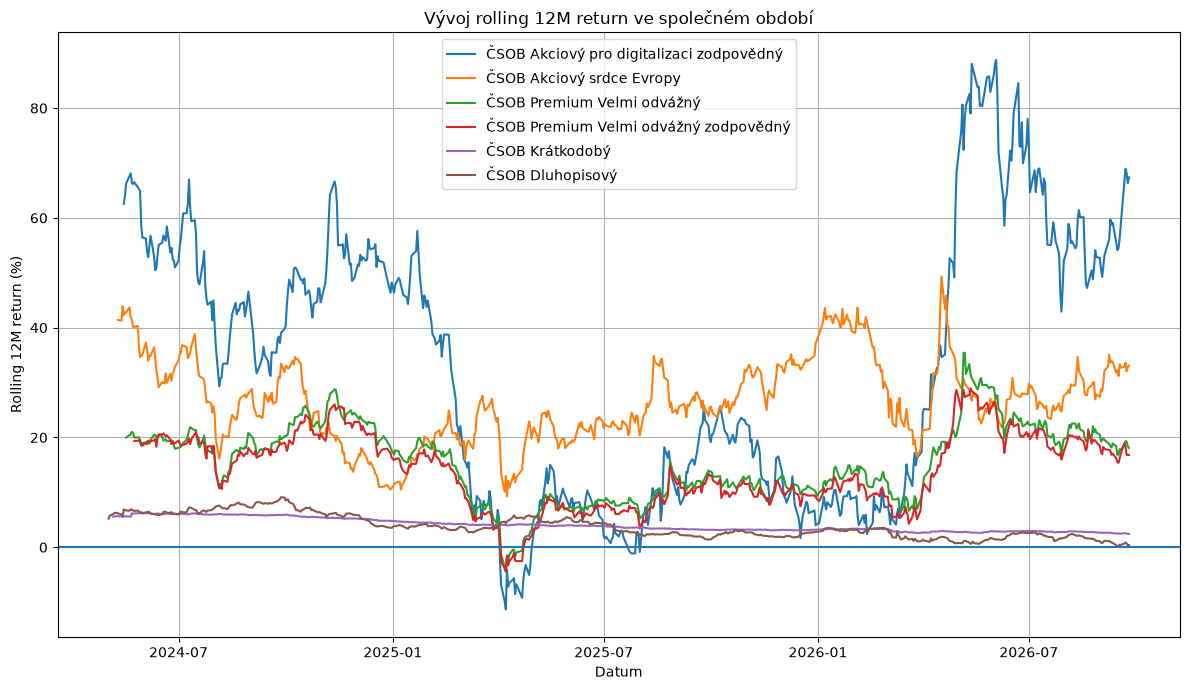

In [17]:
# ============================================================
# 4.3 STABILITA VÝKONNOSTI
#
# Analytická otázka:
# Jak stabilní byla výkonnost jednotlivých fondů v čase?
#
# Cíl:
# Porovnat:
# - minimum a maximum rolling 12M return;
# - průměr a medián rolling 12M return;
# - průběh rolling 12M return v čase.
# ============================================================

# Souhrn rolling 12M return podle fondu.

rolling_12m_summary = (
    analysis_df.groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ],
        as_index=False
    )
    .agg(
        min_rolling_12m_return=("rolling_12m_return", "min"),
        max_rolling_12m_return=("rolling_12m_return", "max"),
        mean_rolling_12m_return=("rolling_12m_return", "mean"),
        median_rolling_12m_return=("rolling_12m_return", "median")
    )
)

print()
print("=" * 60)
print("ROLLING 12M RETURN PODLE FONDU")
print("=" * 60)
print(
    rolling_12m_summary.to_string(
        index=False
    )
)

# Graf vývoje rolling 12M return.

plt.figure(
    figsize=(12, 7)
)

for fund_name in analysis_df["fund_name"].unique():
    fund_data = analysis_df[
        analysis_df["fund_name"] == fund_name
    ]

    plt.plot(
        fund_data["calendar_date"],
        fund_data["rolling_12m_return"] * 100,
        label=fund_name
    )

plt.title(
    "Vývoj rolling 12M return ve společném období"
)

plt.xlabel(
    "Datum"
)

plt.ylabel(

    "Rolling 12M return (%)"
)

plt.axhline(
    y=0
)

plt.legend()

plt.grid()

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.tight_layout()

plt.show()

In [18]:
# ============================================================
# 4.4 NEJLEPŠÍ A NEJSLABŠÍ OBDOBÍ
#
# Analytická otázka:
# Jaká byla nejlepší a nejslabší období výkonnosti
# jednotlivých fondů?
#
# Cíl:
# Najít pro každý fond:
# - nejvyšší rolling 12M return,
# - nejnižší rolling 12M return,
# - začátek rolling 12M období,
# - konec rolling 12M období.
# ============================================================

# Získání počátečního data rolling 12M období.

analysis_df["rolling_12m_start_date"] = (
    analysis_df
    .groupby("fund_key")["calendar_date"]
    .shift(
        periods=252
    )
)

# Získání indexu nejlepšího rolling 12M return pro každý fond.

best_12m_index = (
    analysis_df
    .groupby("fund_key")["rolling_12m_return"]
    .idxmax()
)

# Získání indexu nejslabšího rolling 12M return pro každý fond.

worst_12m_index = (
    analysis_df
    .groupby("fund_key")["rolling_12m_return"]
    .idxmin()
)

# Získání řádků s nejlepším rolling 12M return.

best_12m_rows = analysis_df.loc[
    best_12m_index,
    [
        "fund_key",
        "fund_name",
        "fund_category",
        "rolling_12m_start_date",
        "calendar_date",
        "rolling_12m_return"
    ]
]

# Získání řádků s nejslabším rolling 12M return.

worst_12m_rows = analysis_df.loc[
    worst_12m_index,
    [
        "fund_key",
        "fund_name",
        "fund_category",
        "rolling_12m_start_date",
        "calendar_date",
        "rolling_12m_return"
    ]
]

print()
print("=" * 60)
print("NEJLEPŠÍ 12M OBDOBÍ")
print("=" * 60)
print(
    best_12m_rows.to_string(
        index=False
    )
)

print()
print("=" * 60)
print("NEJSLABŠÍ 12M OBDOBÍ")
print("=" * 60)
print(
    worst_12m_rows.to_string(
        index=False
    )
)


NEJLEPŠÍ 12M OBDOBÍ
 fund_key                                fund_name fund_category rolling_12m_start_date calendar_date  rolling_12m_return
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový             2025-05-07    2026-06-03            0.888007
        2                ČSOB Akciový srdce Evropy       Akciový             2025-04-07    2026-04-17            0.493572
        3               ČSOB Premium Velmi odvážný       Smíšený             2025-04-08    2026-05-07            0.354455
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený             2025-04-16    2026-05-12            0.289183
        5                          ČSOB Krátkodobý   Dluhopisový             2023-05-22    2024-05-28            0.062340
        6                         ČSOB Dluhopisový   Dluhopisový             2023-09-27    2024-09-27            0.091096

NEJSLABŠÍ 12M OBDOBÍ
 fund_key                                fund_name fund_category rolling_12m_start_date calendar_date  

In [19]:
# ============================================================
# 4.5 ROZDÍLY MEZI KATEGORIEMI
#
# Analytická otázka:
# Jaké rozdíly lze pozorovat mezi vybranými akciovými,
# smíšenými a dluhopisovými fondy?
#
# Poznámka:
# V každé kategorii jsou pouze 2 záměrně vybrané fondy.
# Výsledky proto popisují pouze tento vybraný vzorek
# a nelze je zobecňovat na celé kategorie fondů.
# ============================================================

# Přehled dosud vypočtených metrik podle jednotlivých fondů.

category_comparison = (
    analysis_df
    .groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ]
    )
    .agg(
        cumulative_return=("cumulative_return", "last"),
        maximum_drawdown=("drawdown", "min"),
        rolling_12m_min=("rolling_12m_return", "min"),
        rolling_12m_max=("rolling_12m_return", "max"),
        rolling_12m_mean=("rolling_12m_return", "mean")
    )
    .reset_index()
)

print()
print("=" * 60)
print("POROVNÁNÍ FONDŮ PODLE KATEGORIÍ")
print("=" * 60)
print(
    category_comparison.to_string(
        index=False
    )
)


POROVNÁNÍ FONDŮ PODLE KATEGORIÍ
 fund_key                                fund_name fund_category  cumulative_return  maximum_drawdown  rolling_12m_min  rolling_12m_max  rolling_12m_mean
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový           2.098080         -0.283459        -0.113306         0.888007          0.328120
        2                ČSOB Akciový srdce Evropy       Akciový           1.307006         -0.123338         0.092680         0.493572          0.266919
        3               ČSOB Premium Velmi odvážný       Smíšený           0.592369         -0.142418        -0.041718         0.354455          0.153908
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený           0.556584         -0.141350        -0.044406         0.289183          0.138895
        5                          ČSOB Krátkodobý   Dluhopisový           0.137140         -0.005963         0.024270         0.062340          0.040403
        6                         ČSOB Dluh

In [20]:
# ============================================================
# 4.6 KORELACE A SPOLEČNÉ POKLESY
#
# Analytická otázka:
# Do jaké míry se fondy pohybují společně
# a jak se chovají během poklesů?
#
# Cíl:
# - porovnat korelaci denních výnosů;
# - identifikovat společné poklesové dny;
# - ověřit pozorování z předchozí EDA.
# ============================================================


# Převod denních výnosů z long do wide formátu.

daily_return_pivot = analysis_df.pivot(
    index="calendar_date",
    columns="fund_name",
    values="daily_return"
)

# Výpočet korelace denních výnosů.

return_correlation = (
    daily_return_pivot
    .corr()
)

print()
print("=" * 60)
print("KORELACE DENNÍCH VÝNOSŮ")
print("=" * 60)
print(
    return_correlation.to_string()
)

# ============================================================
# SPOLEČNÉ POKLESY
#
# Cíl:
# Zjistit, kolik fondů mělo ve stejný den záporný výnos.
#
# Používáme pouze dny, kdy je dostupný denní výnos
# pro všech 6 fondů.
# ============================================================

# Výpočet počtu klesajících fondů v jednotlivých dnech.

common_declines = (
    (daily_return_pivot.dropna() < 0)
    .sum(axis=1)
)

print()
print("=" * 60)
print("POČET KLESAJÍCÍCH FONDŮ PODLE DNE")
print("=" * 60)
print(
    common_declines.head(10).to_string()
)

# Výběr dnů, kdy klesalo alespoň 5 z 6 fondů.

strong_common_declines = common_declines[
    common_declines >= 5
]

print()
print("=" * 60)
print("DNY, KDY KLESALO ALESPOŇ 5 Z 6 FONDŮ")
print("=" * 60)
print(
    strong_common_declines.to_string()
)

# Souhrn podle počtu klesajících fondů.

decline_summary = (
    common_declines
    .value_counts()
    .sort_index()
)

print()
print("=" * 60)
print("SOUHRN POČTU KLESAJÍCÍCH FONDŮ")
print("=" * 60)
print(
    decline_summary.to_string()
)

# Počet dnů, kdy klesalo všech 6 fondů.

all_funds_decline_days = (
    common_declines == 6
).sum()

# Počet dnů, kdy klesalo alespoň 5 z 6 fondů.

strong_common_decline_days = (
    common_declines >= 5
).sum()

print()
print("=" * 60)
print("SOUHRN SPOLEČNÝCH POKLESŮ")
print("=" * 60)
print(
    "Počet dnů, kdy klesalo všech 6 fondů: "
    + str(all_funds_decline_days)
)

print(
    "Počet dnů, kdy klesalo alespoň 5 z 6 fondů: "
    + str(strong_common_decline_days)
)


KORELACE DENNÍCH VÝNOSŮ
fund_name                                 ČSOB Akciový pro digitalizaci zodpovědný  ČSOB Akciový srdce Evropy  ČSOB Dluhopisový  ČSOB Krátkodobý  ČSOB Premium Velmi odvážný  ČSOB Premium Velmi odvážný zodpovědný
fund_name                                                                                                                                                                                                          
ČSOB Akciový pro digitalizaci zodpovědný                                  1.000000                   0.259265          0.120457         0.104089                    0.795699                               0.787546
ČSOB Akciový srdce Evropy                                                 0.259265                   1.000000          0.277575         0.195206                    0.489834                               0.472161
ČSOB Dluhopisový                                                          0.120457                   0.277575          1.000000

In [21]:
# ============================================================
# 5. HLAVNÍ KPI
#
# Cíl:
# Dokončit a sjednotit hlavní KPI:
# - cumulative return;
# - CAGR;
# - annualized volatility;
# - maximum drawdown;
# - recovery time.
# ============================================================


# ============================================================
# 5.1 CAGR
#
# Cíl:
# Spočítat průměrné roční tempo růstu za celé
# společné analytické období.
#
# CAGR zohledňuje složené úročení a délku období.
# ============================================================


# Výpočet délky společného období v letech.

analysis_years = (
    (common_end_date - common_start_date).days
    / 365.25
)

print()
print("=" * 60)
print("DÉLKA SPOLEČNÉHO OBDOBÍ")
print("=" * 60)
print(
    "Počet let: "
    + str(analysis_years)
)

# Výpočet počáteční a konečné NAV hodnoty pro každý fond.

cagr_summary = (
    analysis_df
    .groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ],
        as_index=False
    )
    .agg(
        first_nav=("nav_value", "first"),
        last_nav=("nav_value", "last")
    )
)


# Výpočet CAGR.

cagr_summary["cagr"] = (
    (
        cagr_summary["last_nav"]
        / cagr_summary["first_nav"]
    )
    ** (1 / analysis_years)
    - 1
)

print()
print("=" * 60)
print("CAGR PODLE FONDU")
print("=" * 60)
print(
    cagr_summary.to_string(
        index=False
    )
)

# ============================================================
# 5.2 ANUALIZOVANÁ VOLATILITA
#
# Cíl:
# Spočítat volatilitu denních výnosů
# a převést ji na roční úroveň.
#
# Annualized volatility:
# směrodatná odchylka denních výnosů
# × odmocnina z 252.
# ============================================================


annualized_volatility_summary = (
    analysis_df
    .groupby(
        [
            "fund_key",
            "fund_name",
            "fund_category"
        ],
        as_index=False
    )
    .agg(
        daily_volatility=("daily_return", "std")
    )
)

annualized_volatility_summary["annualized_volatility"] = (
    annualized_volatility_summary["daily_volatility"]
    * (252 ** 0.5)
)

print()
print("=" * 60)
print("ANUALIZOVANÁ VOLATILITA PODLE FONDU")
print("=" * 60)

print(
    annualized_volatility_summary.to_string(
        index=False
    )
)


# ============================================================
# 5.3 FINÁLNÍ KPI SOUHRN
#
# Cíl:
# Spojit všechny hlavní KPI do jedné tabulky:
# - cumulative return;
# - CAGR;
# - annualized volatility;
# - maximum drawdown;
# - recovery time.
# ============================================================

# Základ finální KPI tabulky.

kpi_summary = category_comparison[
    [
        "fund_key",
        "fund_name",
        "fund_category",
        "cumulative_return",
        "maximum_drawdown"
    ]
]

# Připojení CAGR.

kpi_summary = kpi_summary.merge(
    cagr_summary[
        [
            "fund_key",
            "cagr"
        ]
    ],
    on="fund_key",
    how="left"
)

# Připojení annualized volatility.

kpi_summary = kpi_summary.merge(
    annualized_volatility_summary[
        [
            "fund_key",
            "annualized_volatility"
        ]
    ],
    on="fund_key",
    how="left"
)

# Připojení recovery time.

kpi_summary = kpi_summary.merge(
    recovery_summary[
        [
            "fund_key",
            "recovery_days",
            "recovered"
        ]
    ],
    on="fund_key",
    how="left"
)

print()
print("=" * 60)
print("FINÁLNÍ KPI SOUHRN")
print("=" * 60)
print(
    kpi_summary.to_string(
        index=False
    )
)


DÉLKA SPOLEČNÉHO OBDOBÍ
Počet let: 3.4113620807665983

CAGR PODLE FONDU
 fund_key                                fund_name fund_category  first_nav  last_nav     cagr
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový  1000.0000 3098.0800 0.393022
        2                ČSOB Akciový srdce Evropy       Akciový     0.4710    1.0866 0.277684
        3               ČSOB Premium Velmi odvážný       Smíšený  1358.4100 2163.0900 0.146111
        4    ČSOB Premium Velmi odvážný zodpovědný       Smíšený     0.9941    1.5474 0.138500
        5                          ČSOB Krátkodobý   Dluhopisový   135.4090  153.9790 0.038392
        6                         ČSOB Dluhopisový   Dluhopisový     1.4561    1.6263 0.032936

ANUALIZOVANÁ VOLATILITA PODLE FONDU
 fund_key                                fund_name fund_category  daily_volatility  annualized_volatility
        1 ČSOB Akciový pro digitalizaci zodpovědný       Akciový          0.014559               0.231115
        2    

In [22]:
# ============================================================
# 6. HYPOTÉZY NA ZÁKLADĚ EDA
# 
# Hypotéza 1 – souvislost denních výnosů obou smíšených fondů:
#
# H0: Mezi denními výnosy fondů ČSOB Premium Velmi odvážný
# a ČSOB Premium Velmi odvážný zodpovědný není statisticky
# významná souvislost.
# H1: Mezi denními výnosy těchto dvou fondů existuje kladná
# statisticky významná souvislost.
#
# Hypotéza 2 – souvislost fondu Digitalizace se smíšenými fondy:
# H0: Mezi denními výnosy fondu Digitalizace a vybraných 
# smíšených fondů není statisticky významná souvislost.
# H1: Mezi denními výnosy fondu Digitalizace a vybraných 
# smíšených fondů existuje kladná statisticky významná 
# souvislost.
#
# Obě hypotézy budou ověřeny pomocí Pearsonovy a Spearmanovy
# korelace.
# ============================================================

In [23]:
# ============================================================
# 7. SDA
# 7.1 OVĚŘENÍ SOUVISLOSTI OBOU SMÍŠENÝCH FONDŮ
#
# Hypotéza:
#
# H0:
# Mezi denními výnosy obou smíšených fondů
# není kladná korelace.
#
# H1:
# Mezi denními výnosy obou smíšených fondů
# existuje kladná korelace.
#
# Použité testy:
# - Pearsonova korelace;
# - Spearmanova korelace.
# ============================================================


from scipy.stats import pearsonr, spearmanr

fund_a = "ČSOB Premium Velmi odvážný"
fund_b = "ČSOB Premium Velmi odvážný zodpovědný"

# Výběr pouze dnů, kdy mají oba fondy dostupný denní výnos.

pair_data = (
    daily_return_pivot[
        [
            fund_a,
            fund_b
        ]
    ]
    .dropna()
)


# Pearsonova korelace.

pearson_result = pearsonr(
    pair_data[fund_a],
    pair_data[fund_b],
    alternative="greater"
)

# Spearmanova korelace.

spearman_result = spearmanr(
    pair_data[fund_a],
    pair_data[fund_b],
    alternative="greater"
)

print()
print("=" * 60)
print("SDA – OBA SMÍŠENÉ FONDY")
print("=" * 60)
print(
    "Počet společných pozorování: "
    + str(len(pair_data))
)
print()
print(
    "Pearson correlation: "
    + str(pearson_result.statistic)
)
print(
    "Pearson p-value: "
    + str(pearson_result.pvalue)
)
print()
print(
    "Spearman correlation: "
    + str(spearman_result.statistic)
)
print(
    "Spearman p-value: "
    + str(spearman_result.pvalue)
)

# ============================================================
# 7.2 OVĚŘENÍ SOUVISLOSTI FONDU DIGITALIZACE
# SE SMÍŠENÝMI FONDY
#
# Cíl:
# Ověřit dvě silné korelace nalezené v EDA:
#
# - Digitalizace × Premium Velmi odvážný;
# - Digitalizace × Premium Velmi odvážný zodpovědný.
#
# Použité testy:
# - Pearsonova korelace;
# - Spearmanova korelace.
# ============================================================


fund_digitalization = (
    "ČSOB Akciový pro digitalizaci zodpovědný"
)

fund_mixed_1 = (
    "ČSOB Premium Velmi odvážný"
)

fund_mixed_2 = (
    "ČSOB Premium Velmi odvážný zodpovědný"
)

# ============================================================
# Digitalizace × Premium Velmi odvážný
# ============================================================

pair_data_1 = (
    daily_return_pivot[
        [
            fund_digitalization,
            fund_mixed_1
        ]
    ]
    .dropna()
)

pearson_result_1 = pearsonr(
    pair_data_1[fund_digitalization],
    pair_data_1[fund_mixed_1],
    alternative="greater"
)

spearman_result_1 = spearmanr(
    pair_data_1[fund_digitalization],
    pair_data_1[fund_mixed_1],
    alternative="greater"
)

print()
print("=" * 60)
print("SDA – DIGITALIZACE × PREMIUM VELMI ODVÁŽNÝ")
print("=" * 60)
print(
    "Počet společných pozorování: "
    + str(len(pair_data_1))
)
print()
print(
    "Pearson correlation: "
    + str(pearson_result_1.statistic)
)
print(
    "Pearson p-value: "
    + str(pearson_result_1.pvalue)
)
print()
print(
    "Spearman correlation: "
    + str(spearman_result_1.statistic)
)
print(
    "Spearman p-value: "
    + str(spearman_result_1.pvalue)
)

# ============================================================
# Digitalizace × Premium Velmi odvážný zodpovědný
# ============================================================

pair_data_2 = (
    daily_return_pivot[
        [
            fund_digitalization,
            fund_mixed_2
        ]
    ]
    .dropna()
)

pearson_result_2 = pearsonr(
    pair_data_2[fund_digitalization],
    pair_data_2[fund_mixed_2],
    alternative="greater"
)

spearman_result_2 = spearmanr(
    pair_data_2[fund_digitalization],
    pair_data_2[fund_mixed_2],
    alternative="greater"
)

print()
print("=" * 60)
print("SDA – DIGITALIZACE × PREMIUM VELMI ODVÁŽNÝ ZODPOVĚDNÝ")
print("=" * 60)
print(
    "Počet společných pozorování: "
    + str(len(pair_data_2))
)
print()
print(
    "Pearson correlation: "
    + str(pearson_result_2.statistic)
)
print(
    "Pearson p-value: "
    + str(pearson_result_2.pvalue)
)
print()
print(
    "Spearman correlation: "
    + str(spearman_result_2.statistic)
)
print(
    "Spearman p-value: "
    + str(spearman_result_2.pvalue)
)


SDA – OBA SMÍŠENÉ FONDY
Počet společných pozorování: 799

Pearson correlation: 0.9256345187436484
Pearson p-value: 0.0

Spearman correlation: 0.917016867124614
Spearman p-value: 0.0

SDA – DIGITALIZACE × PREMIUM VELMI ODVÁŽNÝ
Počet společných pozorování: 810

Pearson correlation: 0.7956993627909921
Pearson p-value: 2.020059541463951e-178

Spearman correlation: 0.7754455642506074
Spearman p-value: 8.152292583618373e-164

SDA – DIGITALIZACE × PREMIUM VELMI ODVÁŽNÝ ZODPOVĚDNÝ
Počet společných pozorování: 804

Pearson correlation: 0.7875459319248063
Pearson p-value: 4.370270498274715e-171

Spearman correlation: 0.7637674051796658
Spearman p-value: 6.274450184673744e-155


In [24]:
# # ============================================================
# 8. PŘÍPRAVA ANALYTICKÝCH VÝSTUPŮ PRO SQL
#
# Cíl:
# Připravit dva DataFrame:
#
# 1. daily_output_df
#    → denní analytické metriky
#
# 2. summary_output_df
#    → souhrnné KPI podle fondu
# ============================================================

# ============================================================
# 8.1 DENNÍ ANALYTICKÝ VÝSTUP
# ============================================================

daily_output_df = analysis_df[
    [
        "fund_key",
        "date_key",
        "daily_return",
        "normalized_nav",
        "cumulative_return",
        "drawdown",
        "rolling_12m_return"
    ]
].copy()

print()
print("=" * 60)
print("DAILY OUTPUT PRO SQL")
print("=" * 60)
print(
    daily_output_df.head(10).to_string(
        index=False
    )
)
print()
print(
    "Počet řádků: "
    + str(len(daily_output_df))
)
print()
print(
    "Sloupce: "
    + str(daily_output_df.columns.tolist())
)

# ============================================================
# 8.2 SOUHRNNÝ KPI VÝSTUP
# ============================================================

summary_output_df = kpi_summary[
    [
        "fund_key",
        "cumulative_return",
        "cagr",
        "annualized_volatility",
        "maximum_drawdown",
        "recovery_days",
        "recovered"
    ]
].copy()

summary_output_df["period_start"] = common_start_date
summary_output_df["period_end"] = common_end_date

summary_output_df = summary_output_df[
    [
        "fund_key",
        "period_start",
        "period_end",
        "cumulative_return",
        "cagr",
        "annualized_volatility",
        "maximum_drawdown",
        "recovery_days",
        "recovered"
    ]
]

print()
print("=" * 60)
print("SUMMARY OUTPUT PRO SQL")
print("=" * 60)
print(
    summary_output_df.to_string(
        index=False
    )
)
print()
print(
    "Počet řádků: "
    + str(len(summary_output_df))
)
print()
print(
    "Sloupce: "
    + str(summary_output_df.columns.tolist())
)


# ============================================================
# 8.3 ZÁPIS ANALYTICKÝCH VÝSTUPŮ DO SQL
#
# Cíl:
# Uložit analytické výstupy z Pythonu do SQL Serveru.
#
# Analytické tabulky obsahují odvozené výsledky,
# proto při novém výpočtu provedeme full refresh:
#
# 1. odstranit předchozí analytické výsledky;
# 2. vložit aktuální výsledky;
# 3. potvrdit změny pouze při úspěšném zápisu.
# ============================================================

connection = pyodbc.connect(
    connection_string
)

cursor = connection.cursor()

print()
print("Připojení k SQL Serveru je OK.")

daily_insert_query = """
INSERT INTO analytics.FactFundPerformanceDaily (
    fund_key,
    date_key,
    daily_return,
    normalized_nav,
    cumulative_return,
    drawdown,
    rolling_12m_return
)
VALUES (?, ?, ?, ?, ?, ?, ?)
"""

summary_insert_query = """
INSERT INTO analytics.FundPerformanceSummary (
    fund_key,
    period_start,
    period_end,
    cumulative_return,
    cagr,
    annualized_volatility,
    maximum_drawdown,
    recovery_days,
    recovered
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

daily_rows_to_insert = []

for row in daily_output_df.itertuples(index=False):
    daily_rows_to_insert.append(
        (
            int(row.fund_key),
            int(row.date_key),
            None if pd.isna(row.daily_return)
            else float(row.daily_return),
            float(row.normalized_nav),
            float(row.cumulative_return),
            float(row.drawdown),
            None if pd.isna(row.rolling_12m_return)
            else float(row.rolling_12m_return)
        )
    )

summary_rows_to_insert = []

for row in summary_output_df.itertuples(index=False):

    summary_rows_to_insert.append(
        (
            int(row.fund_key),
            pd.to_datetime(row.period_start).date(),
            pd.to_datetime(row.period_end).date(),
            float(row.cumulative_return),
            float(row.cagr),
            float(row.annualized_volatility),
            float(row.maximum_drawdown),
            None if pd.isna(row.recovery_days)
            else int(row.recovery_days),
            int(row.recovered)
        )
    )

sql_write_success = True

try:
    cursor.execute(
        """
        DELETE FROM analytics.FundPerformanceSummary
        """
    )

    cursor.execute(
        """
        DELETE FROM analytics.FactFundPerformanceDaily
        """
    )

    cursor.executemany(
        daily_insert_query,
        daily_rows_to_insert
    )

    cursor.executemany(
        summary_insert_query,
        summary_rows_to_insert
    )

except Exception as error:
    sql_write_success = False

    print()
    print("CHYBA při zápisu analytických výstupů do SQL:")
    print(str(error))


if sql_write_success:
    connection.commit()

    print()
    print("SQL změny byly potvrzeny.")

else:
    connection.rollback()

    print()
    print("SQL změny nebyly potvrzeny. Byl proveden rollback.")

cursor.execute(
    """
    SELECT COUNT(*)
    FROM analytics.FactFundPerformanceDaily
    """
)

daily_row_count = cursor.fetchone()[0]

cursor.execute(
    """
    SELECT COUNT(*)
    FROM analytics.FundPerformanceSummary
    """
)

summary_row_count = cursor.fetchone()[0]

print()
print("=" * 60)
print("SQL ANALYTICKÉ VÝSTUPY - SOUHRN")
print("=" * 60)
print(
    "Připravené denní řádky: "
    + str(len(daily_rows_to_insert))
)
print(
    "Řádky ve FactFundPerformanceDaily: "
    + str(daily_row_count)
)
print(
    "Připravené KPI řádky: "
    + str(len(summary_rows_to_insert))
)
print(
    "Řádky ve FundPerformanceSummary: "
    + str(summary_row_count)
)

cursor.close()

connection.close()

print()
print("Připojení k SQL Serveru bylo ukončeno.")


DAILY OUTPUT PRO SQL
 fund_key  date_key  daily_return  normalized_nav  cumulative_return  drawdown  rolling_12m_return
        1  20230428           NaN         100.000            0.00000   0.00000                 NaN
        1  20230502     -0.010610          98.939           -0.01061  -0.01061                 NaN
        1  20230503     -0.016030          97.353           -0.02647  -0.02647                 NaN
        1  20230504      0.000575          97.409           -0.02591  -0.02591                 NaN
        1  20230505      0.015553          98.924           -0.01076  -0.01076                 NaN
        1  20230508      0.004984          99.417           -0.00583  -0.00583                 NaN
        1  20230509      0.000272          99.444           -0.00556  -0.00556                 NaN
        1  20230510      0.014108         100.847            0.00847   0.00000                 NaN
        1  20230511      0.006148         101.467            0.01467   0.00000         

In [25]:
# ============================================================
# CELKOVÝ VÝSLEDEK A EXIT CODE
# ============================================================

if sql_write_success:
    print("CELKOVÝ VÝSLEDEK: OK")
    sys.exit(0)

else:
    print("CELKOVÝ VÝSLEDEK: CHYBA")
    sys.exit(1)

CELKOVÝ VÝSLEDEK: OK


SystemExit: 0

c:\Users\frant\Documents\data-analytics-workspace\da-end-to-end-projects-portfolio\projects\project-03-api-python-sql-power-bi\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
